## Step 1 — Imports & Setup

In [1]:
import sys, os, pickle, warnings
warnings.filterwarnings('ignore')

# Notebook lives in v2/ — go one level up to reach project root
PROJECT_ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
for subdir in ['', 'src', 'v0']:
    p = os.path.join(PROJECT_ROOT_PATH, subdir)
    if p not in sys.path:
        sys.path.insert(0, p)

from config import PROJECT_ROOT, PREPROC_DIR, OUTPUTS_DIR
from pipeline_evaluate import load_splits
from pipeline_feature_selection import (
    load_lgbm_model,
    get_top_features,
    print_feature_breakdown,
    filter_splits,
    train_xgb_on_top_n,
    evaluate_model,
    print_comparison_table,
)
import xgboost as xgb_lib

MODELS_DIR = OUTPUTS_DIR / 'models'

# Statistical baseline — predict all legitimate
STAT_BASELINE_PR = 0.035

# nb04 results for final comparison
NB04_RESULTS = {
    'nb04 LightGBM':    {'test_roc': 0.8963, 'test_pr': 0.5045},
    'nb04 XGBoost':     {'test_roc': 0.8971, 'test_pr': 0.4944},
    'nb04 Ensemble':    {'test_roc': 0.8998, 'test_pr': 0.5034},
}

# Flag: if model already saved — skip retraining
RETRAIN_XGB = True
MODEL_PATH  = MODELS_DIR / 'model_xgb_top_n.pkl'

# Number of top features to select
TOP_N = 100

print(f'Project root : {PROJECT_ROOT}')
print(f'Preproc dir  : {PREPROC_DIR}')
print(f'Models dir   : {MODELS_DIR}')
print(f'RETRAIN_XGB  : {RETRAIN_XGB}')
print(f'TOP_N        : {TOP_N}')

Project root : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection
Preproc dir  : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\preproc
Models dir   : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models
RETRAIN_XGB  : True
TOP_N        : 100


## Step 2 — Load Splits + Trained LightGBM

In [2]:
# Load preprocessed splits
X_train, X_val, X_test, encoding_map, y_train, y_val, y_test = load_splits(PREPROC_DIR)

# Load trained LightGBM — no retraining, use nb04 model
model_lgbm = load_lgbm_model(MODELS_DIR / 'model_lgbm.pkl')

STEP 1 — Load preprocessed splits
   X_train_lgbm : (354324, 460)  | fraud rate: 3.3833%
   X_val_lgbm   : (118108, 460)    | fraud rate: 3.9041%  (early stopping)
   X_test_lgbm  : (118108, 460)   | fraud rate: 3.4409%  (frozen TEST)
   encoding_map : 32 encoders
   Loaded LightGBM <- C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_lgbm.pkl


## Step 3 — Extract Top-N Features from LightGBM

In [3]:
top_features = get_top_features(
    model_lgbm,
    feature_names = X_train.columns.tolist(),
    top_n         = TOP_N,
)

TOP-100 FEATURES FROM LIGHTGBM
   Rank   Feature                               Importance
   ───────────────────────────────────────────────────────
   1      card1                                      14471
   2      tx_day                                     12560
   3      card2                                      11540
   4      amt_vs_product_median                      11205
   5      TransactionAmt                              9562
   6      addr1                                       9189
   7      tx_dom                                      8249
   8      tx_amt_mean                                 6836  ◄ engineered
   9      hour_vs_typical                             6500  ◄ engineered
   10     tx_amt_max                                  6425  ◄ engineered
   11     tx_amt_std                                  6393  ◄ engineered
   12     tx_hour                                     6267
   13     time_since_last_tx                          6025  ◄ engineered
   14     delt

## Step 4 — Feature Breakdown: Engineered vs V-columns vs Raw

In [4]:
breakdown = print_feature_breakdown(top_features)

FEATURE BREAKDOWN IN TOP-N
   Total selected    : 100
   Engineered (ours) : 17  → ['tx_amt_mean', 'hour_vs_typical', 'tx_amt_max', 'tx_amt_std', 'time_since_last_tx', 'delta_amt', 'tx_amt_min', 'amt_vs_personal_median', 'amt_z_score', 'uid_time_entropy', 'tx_amt_ratio', 'tx_count', 'tx_count_last_30d', 'tx_count_last_7d', 'nunique_P_email', 'tx_count_last_3d', 'nunique_R_email']
   V-columns         : 26
   Raw features      : 57


## Step 5 — Filter Splits to Top-N Features

In [5]:
X_train_f, X_val_f, X_test_f = filter_splits(X_train, X_val, X_test, top_features)

FILTERED SPLITS
   X_train : (354324, 460) → (354324, 100)
   X_val   : (118108, 460)   → (118108, 100)
   X_test  : (118108, 460)  → (118108, 100)  (frozen TEST)


## Step 6 — Train XGBoost (default params) on Top-N Features

In [6]:
if RETRAIN_XGB or not MODEL_PATH.exists():
    model_xgb_topn, y_pred_val = train_xgb_on_top_n(
        X_train_f, y_train,
        X_val_f,   y_val,
        models_dir = MODELS_DIR,
    )
else:
    with open(MODEL_PATH, 'rb') as f:
        model_xgb_topn = pickle.load(f)
    dval       = xgb_lib.DMatrix(X_val_f)
    y_pred_val = model_xgb_topn.predict(
        dval, iteration_range=(0, model_xgb_topn.best_iteration + 1)
    ).astype('float32')
    print(f'Loaded model_xgb_top_n <- {MODEL_PATH}')

TRAINING — XGBoost on Top-N Features (default params)

   Params         : {'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'scale_pos_weight': 28, 'max_depth': 6, 'eta': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.3, 'colsample_bylevel': 0.5, 'min_child_weight': 100, 'seed': 42, 'verbosity': 0}
   num_rounds     : 3000
   early_stopping : 100

   Train : 354,324 rows × 100 features
   Val   : 118,108 rows × 100 features
[0]	train-auc:0.81291	val-auc:0.81353
[100]	train-auc:0.92297	val-auc:0.90509
[200]	train-auc:0.94407	val-auc:0.91580
[300]	train-auc:0.95631	val-auc:0.91957
[400]	train-auc:0.96462	val-auc:0.92184
[500]	train-auc:0.97045	val-auc:0.92281
[599]	train-auc:0.97496	val-auc:0.92229

   Best iteration : 500
   Best val AUC   : 0.922809

   Model saved → C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_xgb_top_n.pkl


## Step 7 — Predict on Test

In [7]:
dtest        = xgb_lib.DMatrix(X_test_f)
y_pred_test  = model_xgb_topn.predict(
    dtest, iteration_range=(0, model_xgb_topn.best_iteration + 1)
).astype('float32')

## Step 8 — Evaluate on Val (informational)

  Val RESULTS — XGBoost Top-100
  Model                         ROC AUC    PR AUC
  ────────────────────────────────────────────────
  Statistical Baseline                —    0.0350
  XGBoost Top-100                0.9228    0.5656   Δ PR=+0.5306


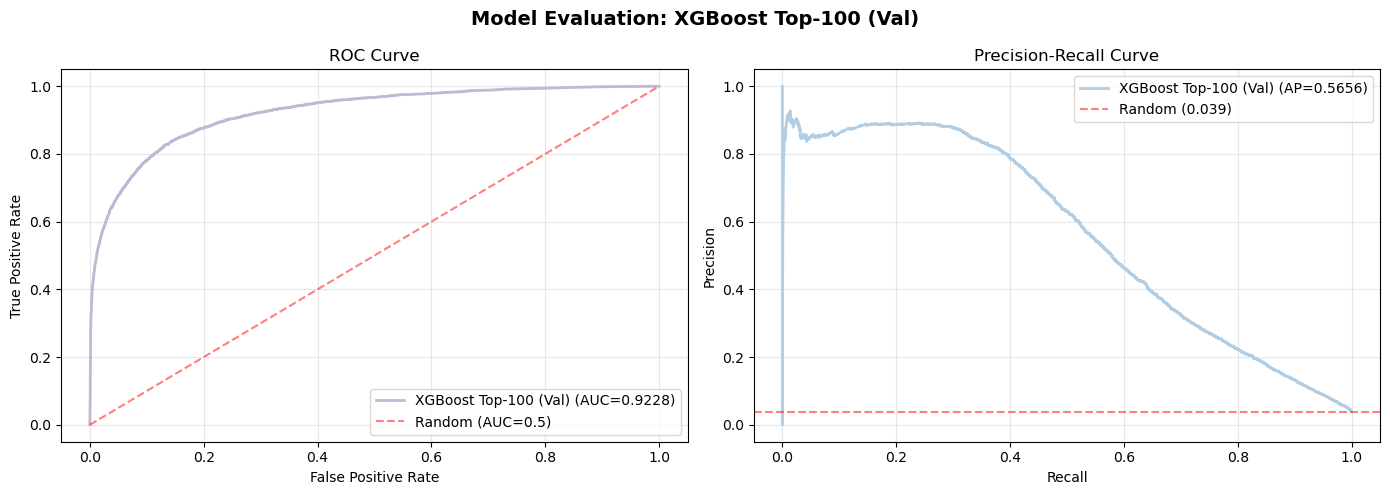

>> Top 30 features by importance:
     1. C5                              importance: 1791.85498046875
     2. C8                              importance: 1692.3956298828125
     3. C10                             importance: 1268.3865966796875
     4. V283                            importance: 1061.9066162109375
     5. C12                             importance: 759.1446533203125
     6. card6                           importance: 735.6874389648438
     7. V317                            importance: 667.069580078125
     8. C14                             importance: 597.3124389648438
     9. V312                            importance: 558.5249633789062
    10. C13                             importance: 544.7696533203125
    11. C11                             importance: 509.9610595703125
    12. V87                             importance: 508.9790344238281
    13. M4                              importance: 494.7781066894531
    14. V308                            importance: 426

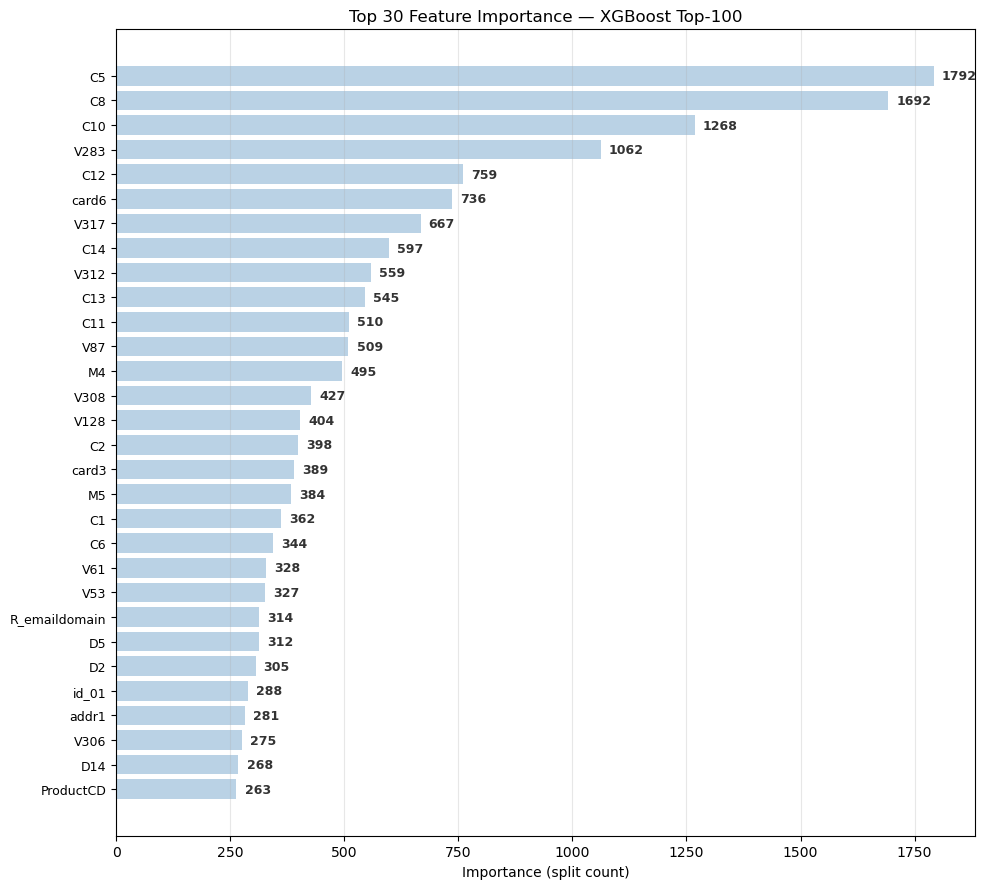

In [8]:
val_roc, val_pr = evaluate_model(
    y_val, y_pred_val,
    model_name   = 'XGBoost Top-100',
    v0_test_roc  = None,
    v0_test_pr   = STAT_BASELINE_PR,
    split_name   = 'Val',
    show_plot    = True,
    model        = model_xgb_topn,
    feature_names = top_features,
)

## Step 9 — Evaluate on Frozen TEST vs Statistical baseline

> ⚠️ **Primary comparison — Test metrics are the only unbiased evaluation.**
> Val metrics are influenced by Optuna tuning and cannot be used as final comparison.

  Test RESULTS — XGBoost Top-100
  Model                         ROC AUC    PR AUC
  ────────────────────────────────────────────────
  Statistical Baseline                —    0.0350
  XGBoost Top-100                0.8899    0.4666   Δ PR=+0.4316


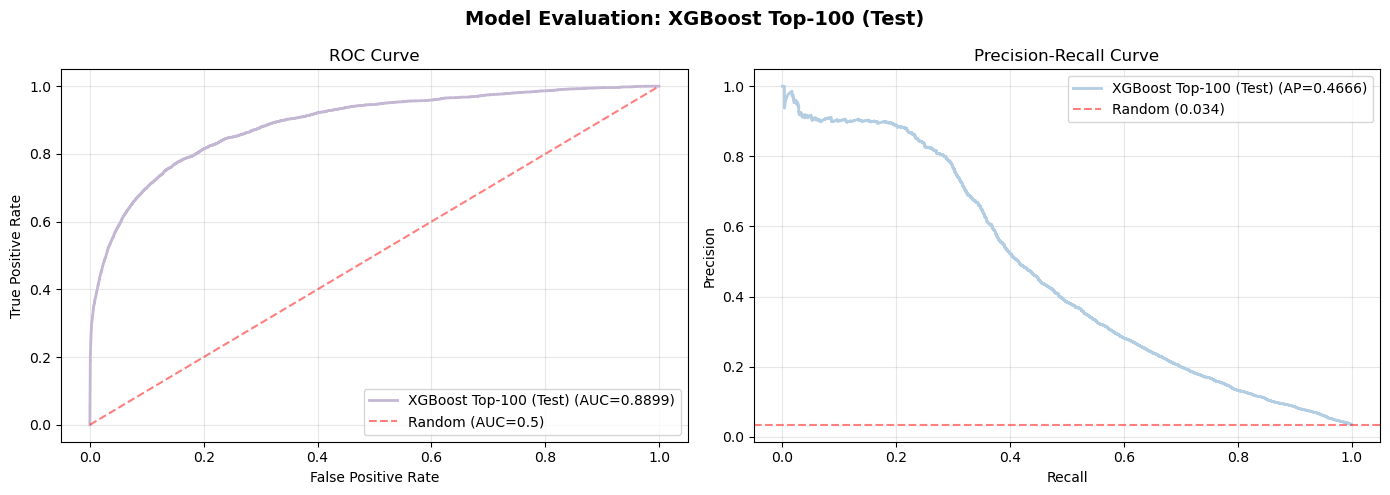

In [9]:
test_roc, test_pr = evaluate_model(
    y_test, y_pred_test,
    model_name   = 'XGBoost Top-100',
    v0_test_roc  = None,
    v0_test_pr   = STAT_BASELINE_PR,
    split_name   = 'Test',
    show_plot    = True,
)

## Step 10 — Final Comparison Table

In [10]:
all_results = {
    **NB04_RESULTS,
    'XGBoost Top-100 (default)': {'test_roc': test_roc, 'test_pr': test_pr},
}

print_comparison_table(all_results, None, STAT_BASELINE_PR)

FINAL COMPARISON — ALL MODELS vs STATISTICAL BASELINE
  Model                             Test ROC   Test PR    Δ ROC     Δ PR
  ────────────────────────────────────────────────────────────────────
  Statistical Baseline                     —    0.0350        —        —
  nb04 LightGBM                       0.8963    0.5045        —  +0.4695
  nb04 XGBoost                        0.8971    0.4944        —  +0.4594
  nb04 Ensemble                       0.8998    0.5034        —  +0.4684
  XGBoost Top-100 (default)           0.8899    0.4666        —  +0.4316


# Step 11 — Conclusion

**Decision rule:**
- If `XGBoost Top-100 Test PR > nb04 XGBoost Test PR (0.4944)`  → feature selection helps → run Optuna
- If `XGBoost Top-100 Test PR > nb04 LightGBM Test PR (0.5045)` → strong result → Optuna is high priority
- If no improvement → reconsider approach (different TOP_N, or focus on LightGBM improvements instead)

**Result: ❌ No improvement.**
- XGBoost Top-100 Test PR = 0.4666 — below nb04 XGBoost (0.4944) and nb04 LightGBM (0.5045)
- XGBoost shifts dominance to C-columns (C5, C8, C10 top-3) — ignores engineered features regardless of feature set size
- **Verdict:** Feature selection does not fix XGBoost's architectural limitation. Focus on LightGBM improvements (V3).